Dataset Shape:
(920, 16)

First 5 Rows:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    

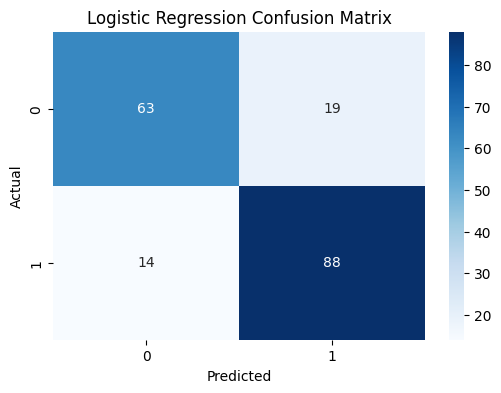

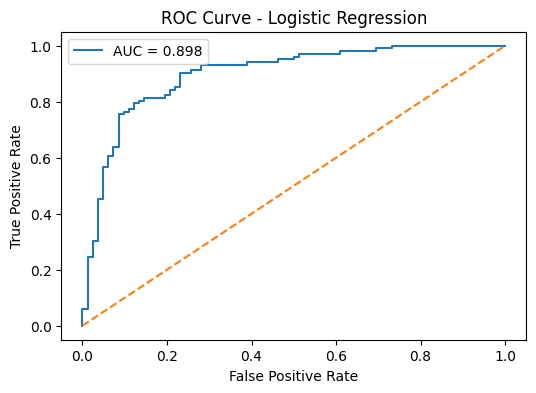

AUC Score: 0.8977

DECISION TREE
Accuracy : 0.8207
Precision: 0.835
Recall   : 0.8431
F1 Score : 0.839

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        82
           1       0.83      0.84      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



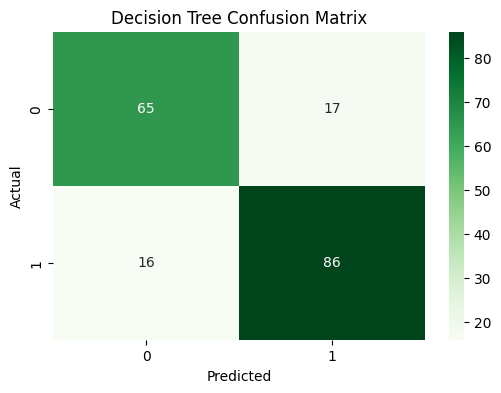


MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.820652   0.822430  0.862745  0.842105
1        Decision Tree  0.820652   0.834951  0.843137  0.839024

Best Model: Logistic Regression
Best Accuracy: 0.8207

Prediction: No Heart Disease


In [1]:
# ============================================
# HEART DISEASE PREDICTION PROJECT
# ============================================

# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("heart_disease_uci.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# ============================================
# DATA CLEANING
# ============================================

print("\nMissing Values:")
print(df.isnull().sum())

# Remove ID column if present

if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

# Convert target variable

df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

# Drop original target column

df.drop('num', axis=1, inplace=True)

# ============================================
# HANDLE MISSING VALUES
# ============================================

# Numerical Columns

numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

if 'target' in numerical_cols:
    numerical_cols.remove('target')

# Categorical Columns

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Fill numerical missing values

num_imputer = SimpleImputer(strategy='median')

df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

# Fill categorical missing values

cat_imputer = SimpleImputer(strategy='most_frequent')

df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# ============================================
# ENCODE CATEGORICAL VARIABLES
# ============================================

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

# ============================================
# FEATURES & TARGET
# ============================================

X = df.drop('target', axis=1)

y = df['target']

# ============================================
# FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

# ============================================
# LOGISTIC REGRESSION
# ============================================

print("\n================================")
print("LOGISTIC REGRESSION")
print("================================")

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# Metrics

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Accuracy :", round(lr_accuracy,4))
print("Precision:", round(lr_precision,4))
print("Recall   :", round(lr_recall,4))
print("F1 Score :", round(lr_f1,4))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================
# ROC CURVE
# ============================================

lr_prob = lr_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, lr_prob)

auc_score = roc_auc_score(y_test, lr_prob)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

print("AUC Score:", round(auc_score,4))

# ============================================
# DECISION TREE
# ============================================

print("\n================================")
print("DECISION TREE")
print("================================")

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

# Metrics

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Accuracy :", round(dt_accuracy,4))
print("Precision:", round(dt_precision,4))
print("Recall   :", round(dt_recall,4))
print("F1 Score :", round(dt_f1,4))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

# ============================================
# DECISION TREE CONFUSION MATRIX
# ============================================

cm2 = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================
# MODEL COMPARISON
# ============================================

results = pd.DataFrame({
    'Model': ['Logistic Regression','Decision Tree'],
    'Accuracy': [lr_accuracy, dt_accuracy],
    'Precision': [lr_precision, dt_precision],
    'Recall': [lr_recall, dt_recall],
    'F1 Score': [lr_f1, dt_f1]
})

print("\n================================")
print("MODEL COMPARISON")
print("================================")

print(results)

# ============================================
# BEST MODEL
# ============================================

best_model = results.loc[
    results['Accuracy'].idxmax(),
    'Model'
]

best_accuracy = results['Accuracy'].max()

print("\nBest Model:", best_model)
print("Best Accuracy:", round(best_accuracy,4))

# ============================================
# SAMPLE PREDICTION
# ============================================

sample = X_test[0].reshape(1, -1)

prediction = lr_model.predict(sample)

if prediction[0] == 1:
    print("\nPrediction: Heart Disease Detected")
else:
    print("\nPrediction: No Heart Disease")

# ============================================
# END OF PROJECT
# ============================================



In [2]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63.0,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,67.0,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1
2,67.0,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,37.0,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,41.0,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0
